# Idea
The idea of this notebook is to create algorithm that could analyse patterns in juno csv files. Such as:
- how often do the values of RxTA peak,
- how long do these values are elevated,
- is there any periodicity about it

In [3]:
import numpy as np
import pandas as pd


# Example 1
Here is an example of how it could be done with numpy array (later the dataframes will be needed for such calculations)

In [4]:
test_array = np.array([1, 2, 3]*30)
test_array = np.concatenate([test_array, np.array([51, 52, 53]*2)])
test_array = np.concatenate([test_array, np.array([1, 2, 3]*10)])
test_array = np.concatenate([test_array, np.array([51, 52, 53]*2)])
test_array = np.concatenate([test_array, np.array([1, 2, 3]*15)])

print(test_array)
print("index, number")
for i, num in enumerate(test_array):
    print(i, num)

[ 1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3
  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3
  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3
  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3 51 52 53 51 52 53
  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3
  1  2  3  1  2  3 51 52 53 51 52 53  1  2  3  1  2  3  1  2  3  1  2  3
  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3  1  2  3
  1  2  3  1  2  3  1  2  3]
index, number
0 1
1 2
2 3
3 1
4 2
5 3
6 1
7 2
8 3
9 1
10 2
11 3
12 1
13 2
14 3
15 1
16 2
17 3
18 1
19 2
20 3
21 1
22 2
23 3
24 1
25 2
26 3
27 1
28 2
29 3
30 1
31 2
32 3
33 1
34 2
35 3
36 1
37 2
38 3
39 1
40 2
41 3
42 1
43 2
44 3
45 1
46 2
47 3
48 1
49 2
50 3
51 1
52 2
53 3
54 1
55 2
56 3
57 1
58 2
59 3
60 1
61 2
62 3
63 1
64 2
65 3
66 1
67 2
68 3
69 1
70 2
71 3
72 1
73 2
74 3
75 1
76 2
77 3
78 1
79 2
80 3
81 1
82 2
83 3
84 1
85 2
86 3
87 1
88 2
89 3
90 51


In [5]:
###### getting indices #######
print("index, number > 50")
indices = []
for i, num in enumerate(test_array):
  if num > 50:
    print(i, num)
    indices.append(i)
print(indices)
# add zero at the end for easier later analysis
indices.append(0)

###### analizing periodicity ######
# counts the number of consecutive indices and the separation between them
# first and last analysis are the test ones and should not be considered in the final analysis
previous_index = 0
count = 1
separation = 0
for i in indices:
  if previous_index == i - 1:
    count += 1
  else:
    print(f"Count of consecutive indices: {count}")
    count = 0
    separation = i - previous_index
    print(f"Separation between indices: {separation}")


  previous_index = i



index, number > 50
90 51
91 52
92 53
93 51
94 52
95 53
126 51
127 52
128 53
129 51
130 52
131 53
[90, 91, 92, 93, 94, 95, 126, 127, 128, 129, 130, 131]
Count of consecutive indices: 1
Separation between indices: 90
Count of consecutive indices: 5
Separation between indices: 31
Count of consecutive indices: 5
Separation between indices: -131


# Testing on real data

In [9]:
# grdr = pd.read_csv("MWR45RG2022272090000_R24733_V04.CSV")
# irdr = pd.read_csv("MWR45RI2022272090000_R24733_V04.CSV")

# grdr2 = pd.read_csv("MWR45RG2022272100000_R30000_V04.CSV")
# irdr2 = pd.read_csv("MWR45RI2022272100000_R30000_V04.CSV")
juno_ri_09 = pd.read_csv("MWR45RI2022272090000_R24733_V04.CSV",header=0, usecols=["t_ephem_time", "R1_1TA", "R1_2TA", "R2_1TA", "R2_2TA", "R3TA", "R4TA", "R5TA", "R6TA"])
# names of all of the columns
print(juno_ri_09.columns)

juno_ri_09.head(10)
mask = juno_ri_09["R2_1TA"] > 80
juno_ri_09.loc[mask]
juno_mask = juno_ri_09.loc[mask]
print(juno_mask)



Index(['t_ephem_time', 'R1_1TA', 'R1_2TA', 'R2_1TA', 'R2_2TA', 'R3TA', 'R4TA',
       'R5TA', 'R6TA'],
      dtype='object')
       t_ephem_time  R1_1TA  R1_2TA   R2_1TA   R2_2TA     R3TA    R4TA  \
40     7.177141e+08  14.355  18.483  296.542  296.701  159.068  82.837   
41     7.177141e+08  13.737  16.591  291.244  291.995  151.590  80.006   
42     7.177141e+08  14.108  17.537  269.064  270.032  124.188  66.698   
43     7.177141e+08  14.850  18.483  251.690  252.775  106.108  57.449   
44     7.177141e+08  15.592  20.375  232.960  233.950   87.618  46.926   
...             ...     ...     ...      ...      ...      ...     ...   
24545  7.177176e+08  16.045  19.867  165.626  166.706   34.499  16.802   
24546  7.177176e+08  17.282  20.812  143.058  143.188   26.714  11.368   
24547  7.177176e+08  16.539  21.757  121.723  122.806   20.107   8.203   
24548  7.177176e+08  17.281  22.702  103.472  104.775   15.600   6.360   
24549  7.177176e+08  17.157  21.756   85.097   85.960   12.52

In [ ]:
# now for the analysis for each R2_1TA that is greater than 80
previous_index = 0
count = 1
separation = 0

# index, count, separation
periodicity_data = []

for i, row in juno_mask.iterrows():
  if previous_index == i - 1:
    count += 1
    print(f"Index: {i} | R2_1TA: {row['R2_1TA']} | Count of consecutive indices: {count}")
  else:
    print(f"Index: {i} | R2_1TA: {row['R2_1TA']}")
    print(f"Count of consecutive indices: {count}")
    separation = i - previous_index
    print(f"Separation between indices: {separation}\n")
    periodicity_data.append([i, count, separation])
    count = 0

  previous_index = i
print(periodicity_data)

# convert periodicity data to seconds
# 7 rows ~ 1 sec
for i, datum in enumerate(periodicity_data):
  periodicity_data[i][1] = datum[1] / 7.0
  periodicity_data[i][2] = datum[2] / 7.0
  print(f"index: {periodicity_data[i][0]} | duration: {periodicity_data[i][1]:.2f} seconds | separation: {periodicity_data[i][2]:.2f} seconds")

Index: 40 | R2_1TA: 296.542
Count of consecutive indices: 1
Separation between indices: 40

Index: 41 | R2_1TA: 291.244 | Count of consecutive indices: 1
Index: 42 | R2_1TA: 269.064 | Count of consecutive indices: 2
Index: 43 | R2_1TA: 251.69 | Count of consecutive indices: 3
Index: 44 | R2_1TA: 232.96 | Count of consecutive indices: 4
Index: 45 | R2_1TA: 212.629 | Count of consecutive indices: 5
Index: 46 | R2_1TA: 169.872 | Count of consecutive indices: 6
Index: 47 | R2_1TA: 148.678 | Count of consecutive indices: 7
Index: 144 | R2_1TA: 259.585
Count of consecutive indices: 7
Separation between indices: 97

Index: 145 | R2_1TA: 275.48 | Count of consecutive indices: 1
Index: 146 | R2_1TA: 295.441 | Count of consecutive indices: 2
Index: 147 | R2_1TA: 299.507 | Count of consecutive indices: 3
Index: 148 | R2_1TA: 298.152 | Count of consecutive indices: 4
Index: 149 | R2_1TA: 294.086 | Count of consecutive indices: 5
Index: 150 | R2_1TA: 272.646 | Count of consecutive indices: 6
Index:

# Analysis of R1_1TA channel (Jupiter?)

In [11]:
mask = juno_ri_09["R1_1TA"] > 500
juno_ri_09.loc[mask]
juno_mask = juno_ri_09.loc[mask]
print(juno_mask)


# now for the analysis for each R1_1TA that is greater than 500
previous_index = 0
count = 1
separation = 0

# index, count, separation
periodicity_data = []

for i, row in juno_mask.iterrows():
  if previous_index == i - 1:
    count += 1
    print(f"Index: {i} | R1_1TA: {row['R1_1TA']} | Count of consecutive indices: {count}")
  else:
    print(f"Index: {i} | R1_1TA: {row['R1_1TA']}")
    print(f"Count of consecutive indices: {count}")
    separation = i - previous_index
    print(f"Separation between indices: {separation}\n")
    periodicity_data.append([i, count, separation])
    count = 0

  previous_index = i
print(periodicity_data)

# convert periodicity data to seconds
# 7 rows ~ 1 sec
for i, datum in enumerate(periodicity_data):
  periodicity_data[i][1] = datum[1] / 7.0
  periodicity_data[i][2] = datum[2] / 7.0
  print(f"index: {periodicity_data[i][0]} | duration: {periodicity_data[i][1]:.2f} seconds | separation: {periodicity_data[i][2]:.2f} seconds")


       t_ephem_time   R1_1TA   R1_2TA  R2_1TA  R2_2TA   R3TA   R4TA   R5TA  \
64     7.177141e+08  810.869  811.053   7.984   8.117  7.915  3.627  5.377   
65     7.177141e+08  718.035  719.329   8.108   8.902  7.659  3.297  5.294   
66     7.177141e+08  534.838  534.937   8.108   8.902  7.762  3.297  5.404   
102    7.177142e+08  668.420  668.136   9.235   8.979  7.579  3.329  5.189   
103    7.177142e+08  764.331  764.558   9.112   9.763  7.733  3.565  5.382   
...             ...      ...      ...     ...     ...    ...    ...    ...   
24712  7.177177e+08  997.575  993.385   7.494   9.076  7.873  3.004  5.299   
24713  7.177177e+08  905.028  901.707   8.111   9.076  7.616  3.335  5.216   
24714  7.177177e+08  809.388  808.139   7.741   8.292  7.821  3.429  5.547   
24715  7.177177e+08  619.223  619.114   8.728   9.860  7.257  3.382  5.189   
24716  7.177177e+08  529.522  530.271   8.111   9.076  8.281  3.807  5.575   

        R6TA  
64     3.190  
65     3.259  
66     3.259  
102

# Analyse 9:36 - 12 480 - 13 230

Surface Temperature: ~84 K to 110 K (depending on latitude/time of day)Ocean Boundary Temperature: ~273 KTemperature Difference ($\Delta T$): ~173 KIf the ice is 29 km thick, the mathematically implied thermal gradient ($\Gamma = \Delta T / z$) is ~5.9 K/km.(Accounting for their ± 10 km uncertainty, the gradient sits somewhere between 4.4 K/km and 9.1 K/km).

−227 degrees Celsius at the poles to about −177 degrees Celsius at the equator

In [ ]:
# surface temp
print(f"lowest surface temp:{-227 + 273} K, medium:{-177 + 273} K, largest:{-143 + 273} K")

temp_difference = 273.15 - 96.0
# thermal gradient
print(f"Thermal gradient (K/km) lowest: {temp_difference/39:.2f} K/km, medium {temp_difference/29:.2f} K/km, largest {temp_difference/19:.2f} K/km")

minimum surface temp:46 K, medium:96 K, maximum:130 K
Thermal gradient (K/km) minimum: 4.54 K/km, medium 6.11 K/km, maximum 9.32 K/km


Thermal gradient (K/km) minimum: 4.49 K, medium 6.03 K, maximum 9.21 K


Depth (km),   Temp (K),  Pressure (MPa)
------------------------------------------
       0.0 |       96.0 |            0.00
      15.1 |      188.3 |           18.46
      20.0 |      218.2 |           24.51
      35.1 |      273.1 |           43.45
      40.0 |      273.1 |           49.66


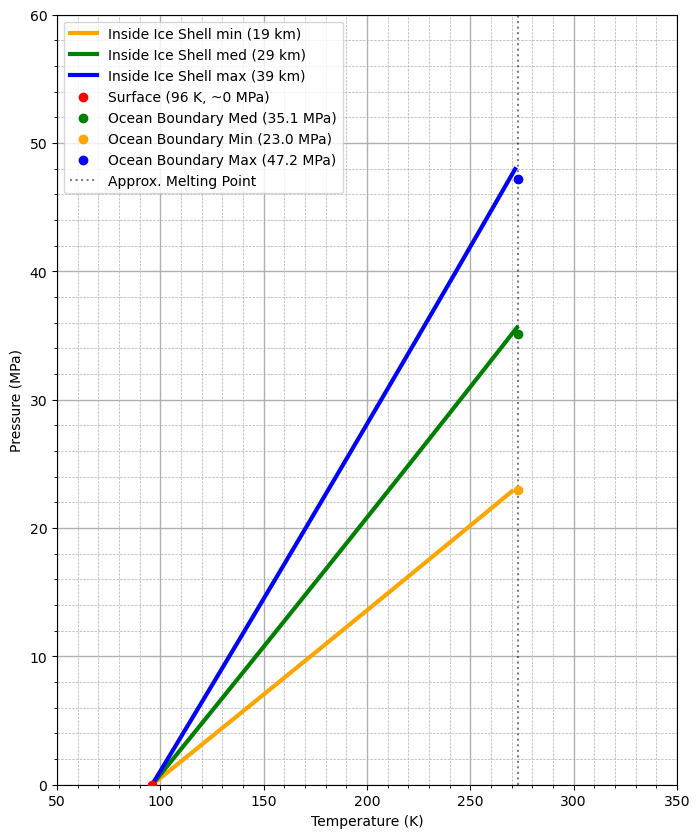

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_SURF = 96.0
T_OCEAN = 273.15
ICE_THICKNESS_KM = [19, 29, 39]

RHO_ICE = 920.0
GRAVITY = 1.315

gamma_max = (T_OCEAN - T_SURF) / ICE_THICKNESS_KM[0]
gamma_med = (T_OCEAN - T_SURF) / ICE_THICKNESS_KM[1]
gamma_min = (T_OCEAN - T_SURF) / ICE_THICKNESS_KM[2]

depths_km = np.linspace(0, ICE_THICKNESS_KM[2] + 5, 100)

temperatures_max = []
temperatures_med = []
temperatures_min = []
pressures_mpa = []

print(f"{'Depth (km)':>10}, {'Temp (K)':>10}, {'Pressure (MPa)':>15}")
print("-" * 42)

for z in depths_km:
    p_mpa = (RHO_ICE * GRAVITY * (z * 1000.0)) / 1e6
    pressures_mpa.append(p_mpa)

    if z <= ICE_THICKNESS_KM[0]:
        temperatures_max.append(T_SURF + (gamma_max * z))
    else:
        temperatures_max.append(T_OCEAN)
    if z <= ICE_THICKNESS_KM[1]:
        temperatures_med.append(T_SURF + (gamma_med * z))
    else:
        temperatures_med.append(T_OCEAN)

    if z <= ICE_THICKNESS_KM[2]:
        temperatures_min.append(T_SURF + (gamma_min * z))
    else:
        temperatures_min.append(T_OCEAN)

    if z == 0 or np.isclose(z % 5, 0, atol=0.2):
        print(f"{z:10.1f} | {temperatures_med[-1]:10.1f} | {p_mpa:15.2f}")


plt.figure(figsize=(8, 10))

ice_mask0 = depths_km <= ICE_THICKNESS_KM[0]
ice_mask1 = depths_km <= ICE_THICKNESS_KM[1]
ice_mask2 = depths_km <= ICE_THICKNESS_KM[2]

plt.plot(np.array(temperatures_max)[ice_mask0], np.array(pressures_mpa)[ice_mask0], '-', linewidth=3, label="Inside Ice Shell min (19 km)", color='orange')

plt.plot(np.array(temperatures_med)[ice_mask1], np.array(pressures_mpa)[ice_mask1],  '-', linewidth=3, label="Inside Ice Shell med (29 km)", color='green')

plt.plot(np.array(temperatures_min)[ice_mask2], np.array(pressures_mpa)[ice_mask2],  '-', linewidth=3, label="Inside Ice Shell max (39 km)", color='blue')

# plt.yscale('log')
plt.xlim(50, 350)
plt.ylim(0.01, 100)

plt.scatter([T_SURF], [0.01], color='red', zorder=5, label='Surface (96 K, ~0 MPa)')
p_boundary = (RHO_ICE * GRAVITY * (ICE_THICKNESS_KM[1] * 1000.0)) / 1e6
plt.scatter([T_OCEAN], [p_boundary], color='green', zorder=5, label=f'Ocean Boundary Med ({p_boundary:.1f} MPa)')

p_boundary = (RHO_ICE * GRAVITY * (ICE_THICKNESS_KM[0] * 1000.0)) / 1e6
plt.scatter([T_OCEAN], [p_boundary], color='yellow', zorder=5, label=f'Ocean Boundary Min ({p_boundary:.1f} MPa)')

p_boundary = (RHO_ICE * GRAVITY * (ICE_THICKNESS_KM[2] * 1000.0)) / 1e6
plt.scatter([T_OCEAN], [p_boundary], color='blue', zorder=5, label=f'Ocean Boundary Max ({p_boundary:.1f} MPa)')

plt.axvline(x=273.15, color='k', linestyle=':', alpha=0.5, label='Approx. Melting Point')

plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (MPa)")
plt.minorticks_on()
# plt.grid(True, which="both", ls="--", alpha=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5)
plt.grid(which='major', linestyle='-', linewidth=1)
plt.legend()
plt.show()

Depth (km),   Temp (K),  Pressure (MPa)
------------------------------------------
       0.0 |       96.0 |            0.00
      15.1 |      188.3 |           18.46
      20.0 |      218.2 |           24.51
      35.1 |      273.1 |           43.45
      40.0 |      273.1 |           49.66


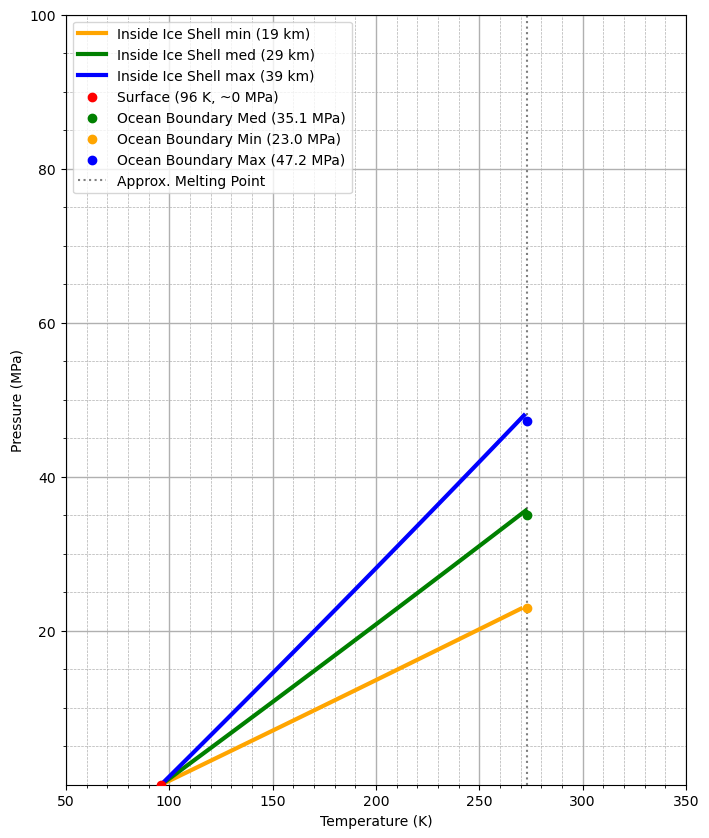

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_SURF = 96.0
T_OCEAN = 273.15
ICE_THICKNESS_KM = [19, 29, 39]

RHO_ICE = 920.0
GRAVITY = 1.315
R_EUROPA_KM = 1560.8

gamma_max = (T_OCEAN - T_SURF) / ICE_THICKNESS_KM[0]
gamma_med = (T_OCEAN - T_SURF) / ICE_THICKNESS_KM[1]
gamma_min = (T_OCEAN - T_SURF) / ICE_THICKNESS_KM[2]

depths_km = np.linspace(0, ICE_THICKNESS_KM[2] + 5, 100)

temperatures_max = []
temperatures_med = []
temperatures_min = []
pressures_mpa = []

print(f"{'Depth (km)':>10}, {'Temp (K)':>10}, {'Pressure (MPa)':>15}")
print("-" * 42)

for z in depths_km:
    r_surf_m = R_EUROPA_KM * 1000.0
    r_depth_m = r_surf_m - (z * 1000.0)
    # # Spherical (Current)
    # p_pa = RHO_ICE * GM * ((1.0 / r_depth_m) - (1.0 / r_surf_m))
    ## Linear (Proposed)
    # p_pa = RHO_ICE * GRAVITY * (z - (z**2 / (2 * R_EUROPA_KM * 1000.0)))

    GM = GRAVITY * (r_surf_m ** 2)

    p_pa = RHO_ICE * GM * ((1.0 / r_depth_m) - (1.0 / r_surf_m))
    p_mpa = p_pa / 1e6
    pressures_mpa.append(p_mpa)

    if z <= ICE_THICKNESS_KM[0]:
        temperatures_max.append(T_SURF + (gamma_max * z))
    else:
        temperatures_max.append(T_OCEAN)

    if z <= ICE_THICKNESS_KM[1]:
        temperatures_med.append(T_SURF + (gamma_med * z))
    else:
        temperatures_med.append(T_OCEAN)

    if z <= ICE_THICKNESS_KM[2]:
        temperatures_min.append(T_SURF + (gamma_min * z))
    else:
        temperatures_min.append(T_OCEAN)

    if z == 0 or np.isclose(z % 5, 0, atol=0.2):
        print(f"{z:10.1f} | {temperatures_med[-1]:10.1f} | {p_mpa:15.2f}")


plt.figure(figsize=(8, 10))

ice_mask0 = depths_km <= ICE_THICKNESS_KM[0]
ice_mask1 = depths_km <= ICE_THICKNESS_KM[1]
ice_mask2 = depths_km <= ICE_THICKNESS_KM[2]

plt.plot(np.array(temperatures_max)[ice_mask0], np.array(pressures_mpa)[ice_mask0],
         '-', linewidth=3, label="Inside Ice Shell min (19 km)", color='orange')

plt.plot(np.array(temperatures_med)[ice_mask1], np.array(pressures_mpa)[ice_mask1],
         '-', linewidth=3, label="Inside Ice Shell med (29 km)", color='green')

plt.plot(np.array(temperatures_min)[ice_mask2], np.array(pressures_mpa)[ice_mask2],
         '-', linewidth=3, label="Inside Ice Shell max (39 km)", color='blue')

# plt.yscale('log')
plt.xlim(50, 350)
plt.ylim(0.01, 100)

plt.scatter([T_SURF], [0.0], color='red', zorder=5, label='Surface (96 K, ~0 MPa)')

p_boundary_med = (RHO_ICE * GRAVITY * (ICE_THICKNESS_KM[1] * 1000.0)) / 1e6
plt.scatter([T_OCEAN], [p_boundary_med], color='green', zorder=5, label=f'Ocean Boundary Med ({p_boundary_med:.1f} MPa)')

p_boundary_min = (RHO_ICE * GRAVITY * (ICE_THICKNESS_KM[0] * 1000.0)) / 1e6
plt.scatter([T_OCEAN], [p_boundary_min], color='orange', zorder=5, label=f'Ocean Boundary Min ({p_boundary_min:.1f} MPa)')

p_boundary_max = (RHO_ICE * GRAVITY * (ICE_THICKNESS_KM[2] * 1000.0)) / 1e6
plt.scatter([T_OCEAN], [p_boundary_max], color='blue', zorder=5, label=f'Ocean Boundary Max ({p_boundary_max:.1f} MPa)')

plt.axvline(x=273.15, color='k', linestyle=':', alpha=0.5, label='Approx. Melting Point')

plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (MPa)")
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth=0.5)
plt.grid(which='major', linestyle='-', linewidth=1)
plt.legend()
plt.show()